# F3NinaB — Eventos e ciclo de vida: La Niña

**Projeto:** NINO-BRASIL — Oceanografia Física — UFPE  
**Código canônico:** `F3NinaB`  
**Objeto de estudo:** ciclo de vida da La Niña no Pacífico tropical  
**Família de hipótese:** `HIP0`

## 1. Contexto e delimitação científica

Este notebook constrói o catálogo local de eventos e a segmentação do ciclo de vida que serão usados por todas as análises posteriores. Gênese, crescimento, faixa de pico e decaimento precisam ter definições reproduzíveis e específicas do sinal, sem emprestar semanas ou limiares do sinal oposto.

## 2. Pergunta científica

Quando começam e terminam gênese, crescimento, faixa de pico e decaimento?

## 3. Hipótese específica

Os eventos de La Niña identificados pela regra ONI local formam trajetórias coerentes em quatro fases, e o pico é melhor representado por uma faixa relativa ao extremo de cada evento do que por uma única semana.

A hipótese poderá ser sustentada, parcialmente sustentada ou rejeitada; a execução do notebook não antecipa o resultado.

## 4. Motivação para o teste e unidade de análise

A regra |ONI| ≥ 0,5 °C por pelo menos cinco estações móveis delimita eventos; a polaridade seleciona apenas La Niña. A faixa de pico é derivada do extremo interno do evento e submetida a sensibilidade, separando caracterização retrospectiva de qualquer alvo preditivo.

## 5. Metodologia

Eventos ONI locais simétricos (|ONI|≥0,5 °C por cinco estações) e faixa de pico relativa ao extremo de cada evento.

## 6. Resultados esperados e contrato de saída

Resultados esperados significam produtos necessários para responder à pergunta, não valores ou significâncias presumidos:

- catálogo de eventos com início, fim, intensidade e duração.
- rótulo semanal de gênese, crescimento, faixa de pico e decaimento.
- tabela de sensibilidade da largura da faixa de pico.

- figuras públicas iniciadas por `FigF3NinaB`;
- tabelas públicas iniciadas por `TabF3NinaB`;
- primeiro par reservado: `FigF3NinaB1` ↔ `TabF3NinaB1`;
- toda interpretação deve apontar para tabela, run_id, unidade, amostra e limitações.

## 7. Fundamentação científica mínima

1. Trenberth, K. E. (1997). The Definition of El Niño. Bulletin of the American Meteorological Society, 78, 2771–2777.
2. Timmermann, A. et al. (2018). El Niño–Southern Oscillation complexity. Nature, 559, 535–545.

## Premissas de validade e limites de interpretação

- Toda conclusão deve nascer de uma tabela `Tab...` persistida antes da figura correspondente.
- A execução é determinística e usa somente entradas declaradas no inventário mostrado abaixo.
- Notebook executado não implica hipótese confirmada; gates científicos são exibidos como resultados.
- El Niño e La Niña são analisados isoladamente; nenhum composto mistura os dois sinais.
- Evento é a unidade independente; semanas descrevem a trajetória interna do evento.

In [1]:
from pathlib import Path
import os
import sys
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
NOTEBOOK_CODE = 'F3NinaB'
MODE = os.environ.get('NINO26_NOTEBOOK_MODE', 'official')
RUN_PIPELINE = os.environ.get('NINO26_RUN_PIPELINE', '0') == '1'
if RUN_PIPELINE:
    raise RuntimeError('O núcleo numérico deve ser executado pelo runner da fase, antes do notebook.')
from nino_brasil.notebook_workflows import NotebookWorkflow
workflow = NotebookWorkflow(ROOT, NOTEBOOK_CODE, mode=MODE)
workflow.describe()

{
  "notebook_code": "F3NinaB",
  "phase": 3,
  "enso_type": "la_nina",
  "mode": "official",
  "execution_policy": "numeric-core-first-viewer-publisher"
}


{'notebook_code': 'F3NinaB',
 'phase': 3,
 'enso_type': 'la_nina',
 'mode': 'official',
 'execution_policy': 'numeric-core-first-viewer-publisher'}

## Dados

In [2]:
input_inventory = workflow.input_inventory()
display(input_inventory)
workflow.require_inputs()

,role,path,required,exists,bytes
0,catálogo completo de eventos,data\processed\parquet\statistics\F3Nina\TabF3...,True,True,3545
1,ciclo de vida canônico,data\processed\parquet\statistics\F3Nina\TabF3...,True,True,4171
2,sensibilidade da faixa de pico,data\processed\parquet\statistics\F3Nina\TabF3...,True,True,3792
3,sensibilidade das quatro fases,data\processed\parquet\statistics\F3Nina\TabF3...,True,True,79649


## Resultados

In [3]:
result = workflow.run()
display(result.artifacts)
display(result.summary)

,notebook_code,ordinal,namespace,figure_code,table_code,figure_path,table_path,manifest_path,figure_sha256,table_sha256,run_id
0,F3NinaB,1,fase3_nina,FigF3NinaB1_ciclos_vida_eventos,TabF3NinaB1_ciclos_vida_eventos,C:\DEV\NINO26\data\processed\figures\fase3_nin...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,76dba1d4899daa11c38523282542d849c4262648b1753f...,ce97755800cf2c878711c8867971ea39c5f4049e7c42d6...,20260714T202702Z_5538a635
1,F3NinaB,2,fase3_nina,FigF3NinaB2_sensibilidade_fronteiras_fases,TabF3NinaB2_sensibilidade_fronteiras_fases,C:\DEV\NINO26\data\processed\figures\fase3_nin...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,caabd65e6d7aa02eedad1a2c995572c0d4cb6d1783516d...,1ae2a2de38ce58cc52617ab045dddc29e02c7f6b975083...,20260714T202702Z_5538a635


,event_id,tipo,classe,fase,inicio,fim,duracao_semanas,modo_rotulo
0,la_nina_1983_1984,la_nina,moderado,genese,1983-03-06,1983-08-28,26,diagnostico_retrospectivo
1,la_nina_1983_1984,la_nina,moderado,crescimento,1983-09-04,1983-10-30,9,diagnostico_retrospectivo
2,la_nina_1983_1984,la_nina,moderado,pico,1983-11-06,1983-12-25,8,diagnostico_retrospectivo
3,la_nina_1983_1984,la_nina,moderado,decaimento,1984-01-01,1984-02-26,9,diagnostico_retrospectivo
4,la_nina_1984_1986,la_nina,moderado,genese,1984-03-04,1984-03-25,4,diagnostico_retrospectivo
5,la_nina_1984_1986,la_nina,moderado,crescimento,1984-04-01,1984-11-25,35,diagnostico_retrospectivo
6,la_nina_1984_1986,la_nina,moderado,pico,1984-12-02,1985-01-27,9,diagnostico_retrospectivo
7,la_nina_1984_1986,la_nina,moderado,decaimento,1985-02-03,1986-04-27,65,diagnostico_retrospectivo
8,la_nina_1988_1989,la_nina,muito_forte,genese,1987-10-04,1988-03-27,26,diagnostico_retrospectivo
9,la_nina_1988_1989,la_nina,muito_forte,crescimento,1988-04-03,1988-10-30,31,diagnostico_retrospectivo


## Figuras para verificação rápida

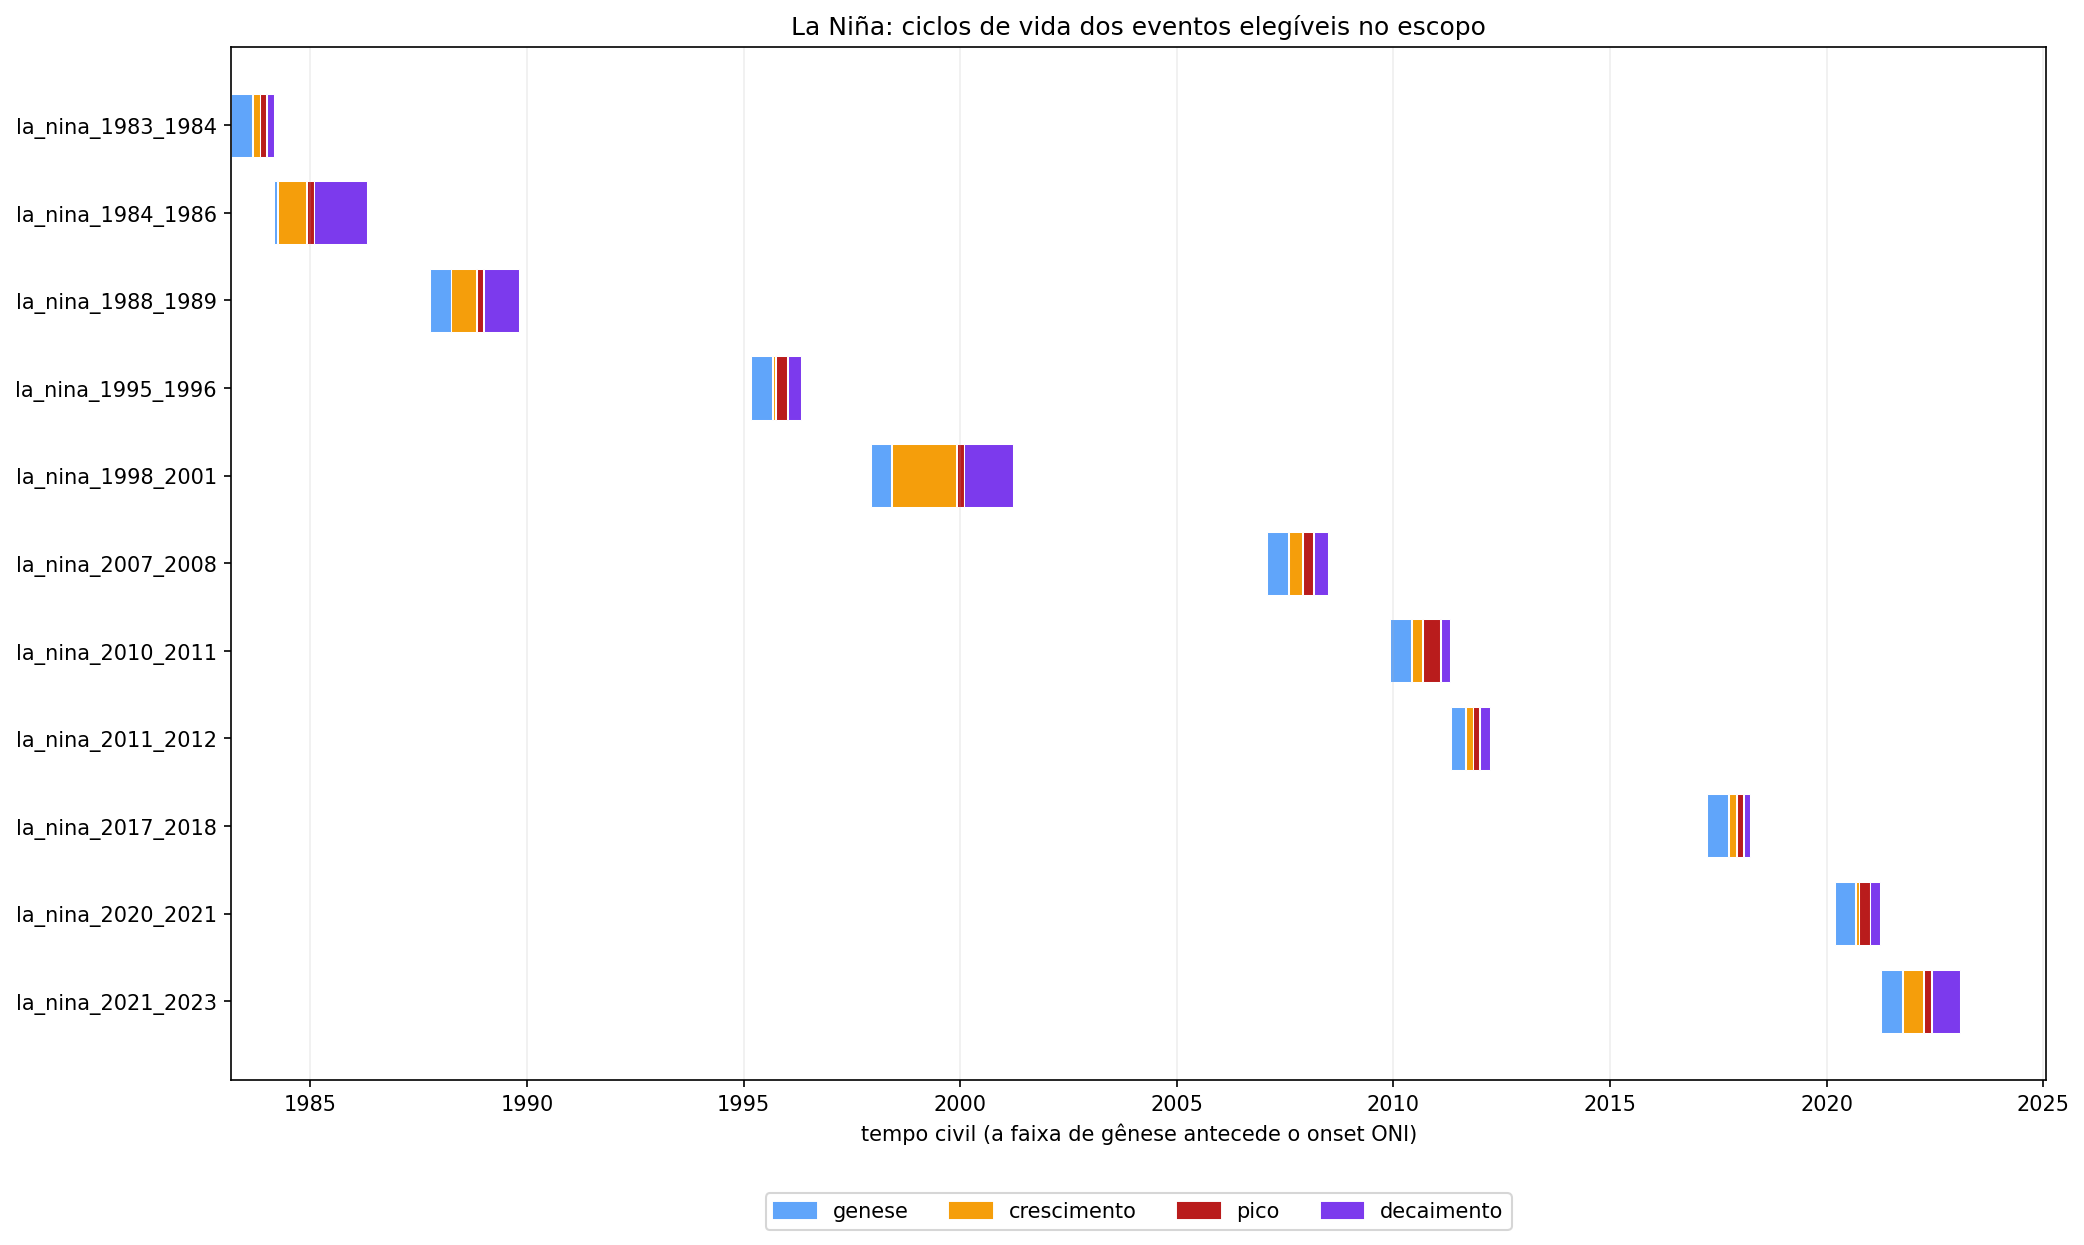

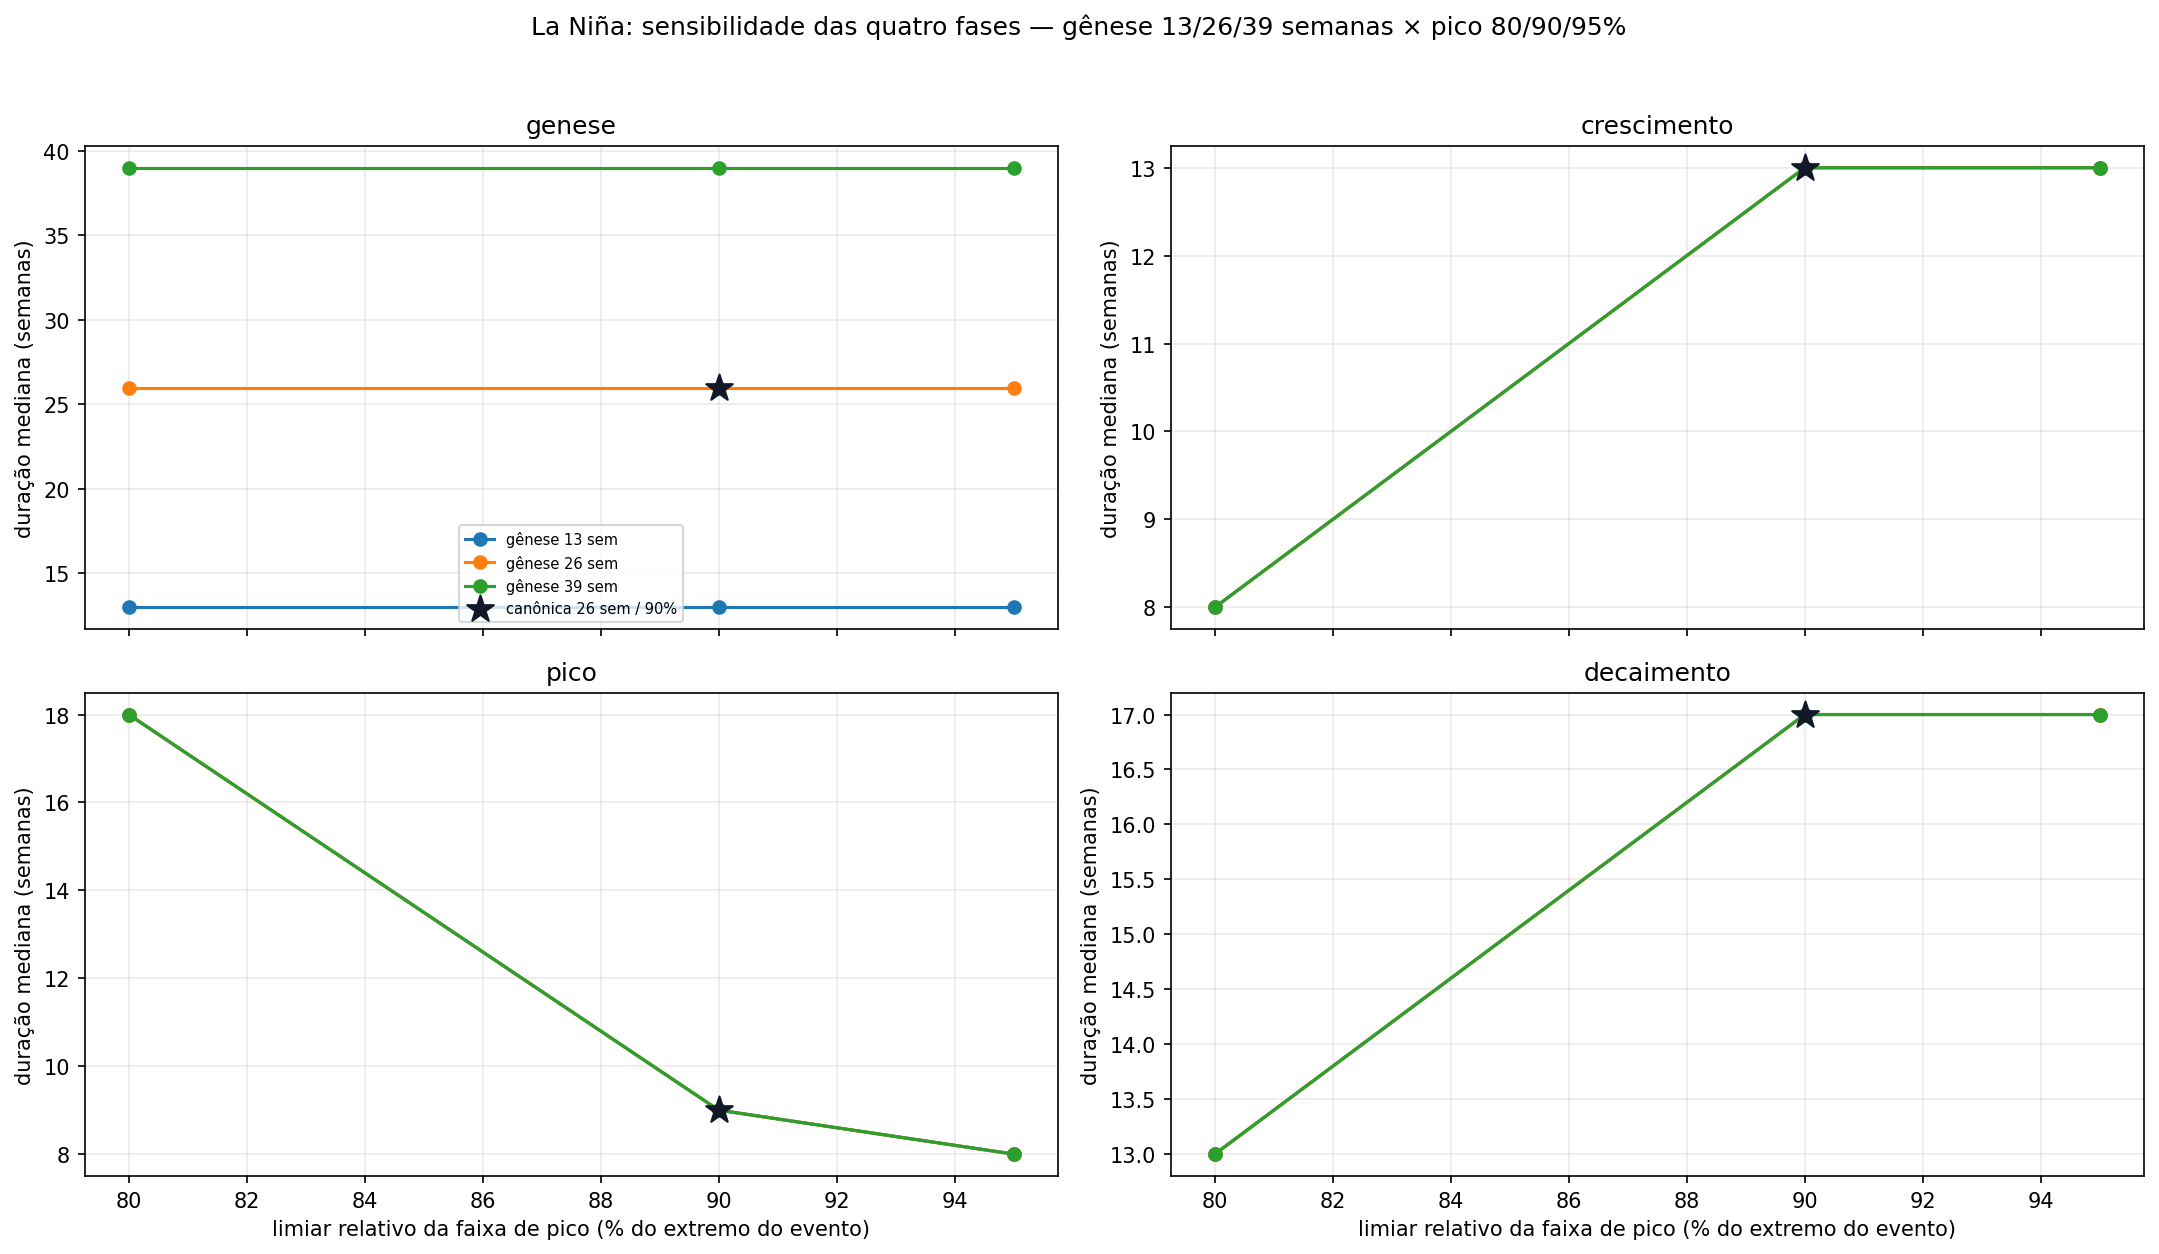

In [4]:
from IPython.display import Image, display

for artifact in result.artifacts.itertuples(index=False):
    display(Image(filename=str(artifact.figure_path)))

## Conclusões

In [5]:
for item in result.takeaways:
    print(f'- {item}')
print('\nLimitações:')
for item in result.limitations:
    print(f'- {item}')

- O catálogo conserva 11 eventos detectados; 11 atendem ao corte de análise (todos os eventos detectados).
- A gênese canônica é uma janela diagnóstica de 26 semanas antes do onset ONI; 13 e 39 semanas medem a dependência dessa escolha.
- A faixa de pico canônica usa 90% do extremo e tem duração mediana de 2.0 meses entre os eventos elegíveis.

Limitações:
- As figuras resumem tabelas auditadas; consulte tabela, manifesto e unidade antes de interpretar valores individuais.
- Leituras de propagação e influência são diagnósticas por evento; não há detector formal de onda nem atribuição causal.
- Somente eventos elegíveis do sinal isolado entram nos painéis; o número de eventos independentes acompanha cada tabela.
